
 FIRST 5 ROWS
                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate  votes                             phone  \
0          Yes        Yes  4.1/5    775    080 42297555\r\n+91 9743772233   
1          Yes     

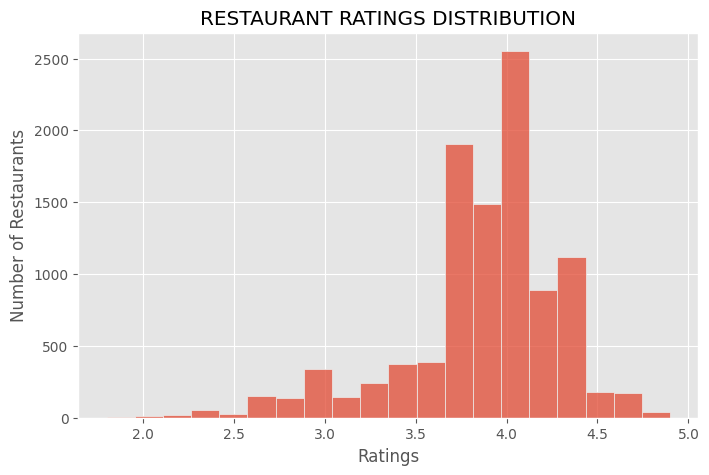

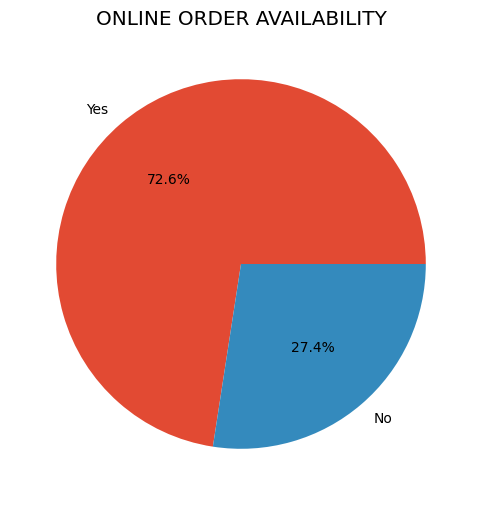

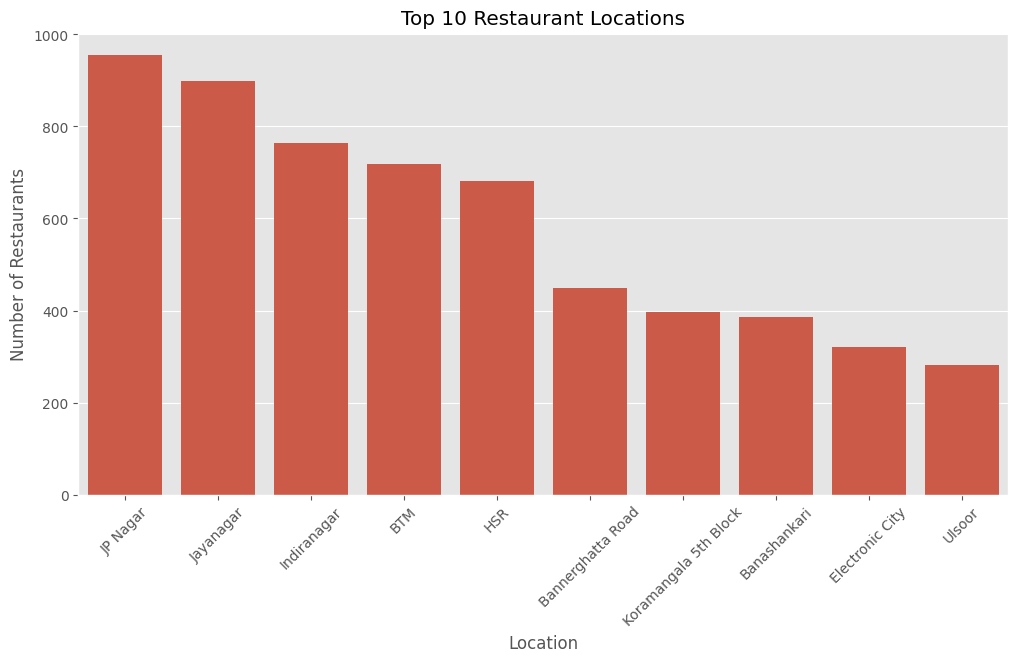

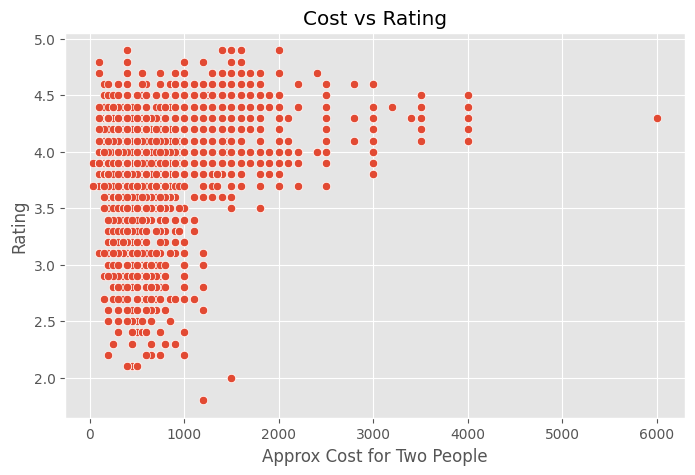

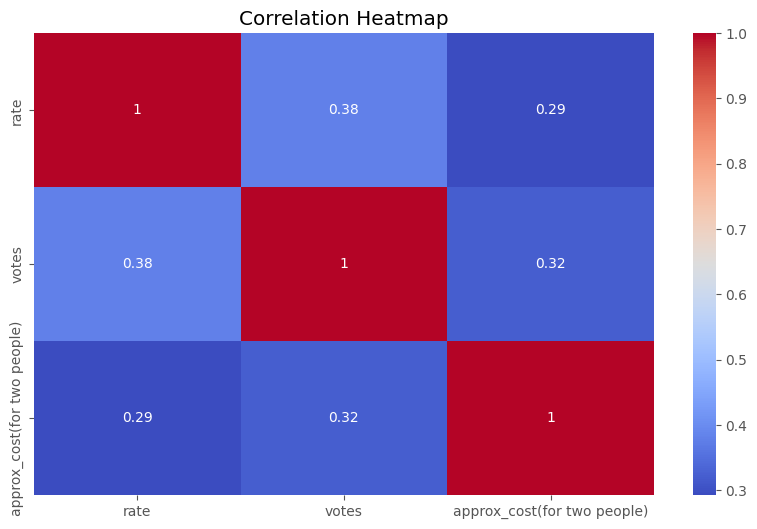

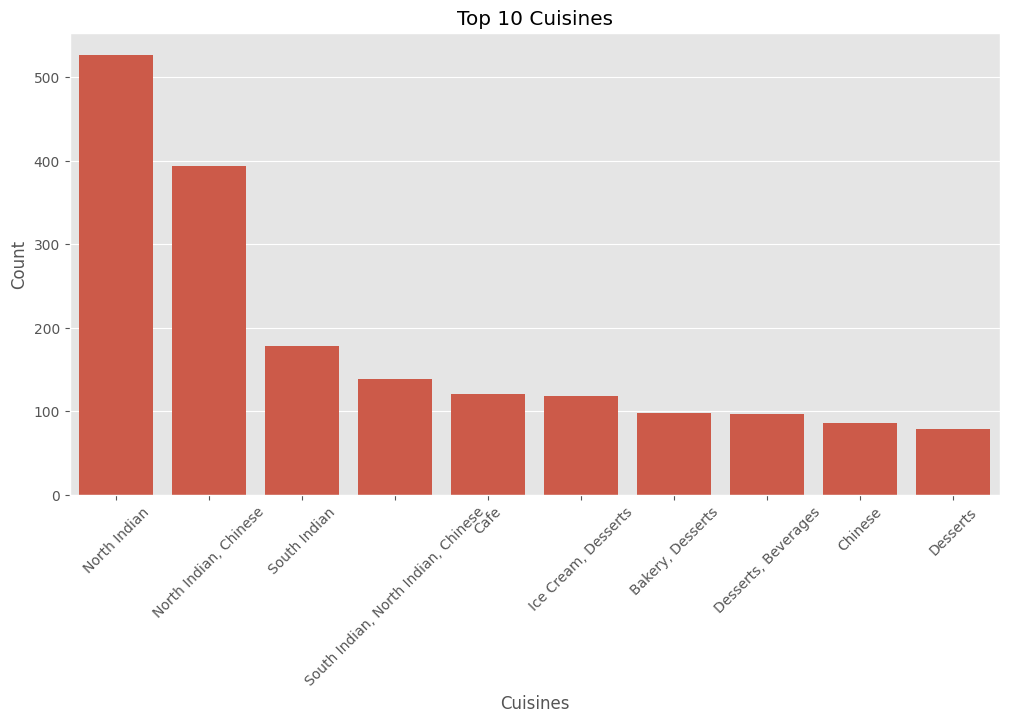


PROJECT CONCLUSIONS
1. Most restaurants support online ordering.
2. Some locations contain a higher number of restaurants.
3. Mid-range restaurants tend to receive better ratings.
4. Popular cuisines dominate the restaurant market.
5. Ratings are mostly concentrated between 3.5 and 4.5.


In [ ]:
#===============================================
#CODEALPHA INTERNSHIP PROJECT
#ZOMATO DATA VISUALIZATION USING PYTHON
#===============================================

#===============================================
#STEP 1 - IMPORT LIB
#===============================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("ggplot")

#=================================================
#STEP -2 LOAD DATASET
#=================================================




df = pd.read_csv(
    "zomato.csv",
    engine='python',
    encoding='latin-1',
    on_bad_lines='skip'
)

df.head()

#=================================================
#STEP -3 DISPLAY
#=================================================
print("\n FIRST 5 ROWS")
print(df.head())
print("\nDATASET INFO")
print(df.info())
print("\nSTATISTICAL SUMMARY")
print(df.describe())
print("\nMISSING VALUES")
print(df.isnull().sum())
df.dropna(inplace=True)
print("\nMISSING VALUES AFTER CLEANING")
print(df.isnull().sum())
#=================================================
#STEP -4 CLEAN RATE COLUMN
#=================================================
# Remove '/5' from ratings
df['rate'] = df['rate'].astype(str)

df = df[df['rate'] != 'NEW']
df = df[df['rate'] != '-']

df['rate'] = df['rate'].str.replace('/5', '')

df['rate'] = df['rate'].astype(float)

# -----------------------------
# STEP 5 - CLEAN COST COLUMN
# -----------------------------

df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '')
)

df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(float)
)
#======================================================
#DATA VISUALIZATION
#======================================================

#=========================================================
#VIS 1-RESTAURANT RATINGS DISTRIBUTION
#=========================================================
plt.figure(figsize=(8,5))
sns.histplot(df['rate'],bins=20)
plt.title("RESTAURANT RATINGS DISTRIBUTION")
plt.xlabel("Ratings")
plt.ylabel("Number of Restaurants")
plt.show()

#============================================================
#VIS -2 ONLINE ORDER AVAILABILITY
#============================================================
df['online_order'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6)
 )
plt.title("ONLINE ORDER AVAILABILITY")
plt.ylabel("")
plt.show()


# -----------------------------
# VISUALIZATION 3
# TOP RESTAURANT LOCATIONS
# -----------------------------

top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_locations.index,
    y=top_locations.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Restaurant Locations")
plt.xlabel("Location")
plt.ylabel("Number of Restaurants")

plt.show()

# -----------------------------
# VISUALIZATION 4
# COST VS RATING
# -----------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='approx_cost(for two people)',
    y='rate',
    data=df
)

plt.title("Cost vs Rating")
plt.xlabel("Approx Cost for Two People")
plt.ylabel("Rating")

plt.show()

# -----------------------------
# VISUALIZATION 5
# HEATMAP
# -----------------------------

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# -----------------------------
# VISUALIZATION 6
# TOP CUISINES
# -----------------------------

top_cuisines = df['cuisines'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_cuisines.index,
    y=top_cuisines.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Cuisines")
plt.xlabel("Cuisines")
plt.ylabel("Count")

plt.show()

# =========================================================
# PROJECT CONCLUSIONS
# =========================================================

print("\nPROJECT CONCLUSIONS")
print("1. Most restaurants support online ordering.")
print("2. Some locations contain a higher number of restaurants.")
print("3. Mid-range restaurants tend to receive better ratings.")
print("4. Popular cuisines dominate the restaurant market.")
print("5. Ratings are mostly concentrated between 3.5 and 4.5.")

# =========================================================
# END OF PROJECT
# ========================================================

